# Book Recommendation Research Project

This notebook compares content-based filtering, collaborative filtering, and a hybrid approach for book recommendation. It also evaluates all three methods and reports the best one for your research project.


In [ ]:
!pip install pandas numpy scikit-learn scipy


In [ ]:
import pandas as pd
import numpy as np
import math
import json

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



In [ ]:
books = pd.read_csv('/content/Books.csv', encoding='latin-1', low_memory=False)
ratings = pd.read_csv('/content/Ratings.csv', low_memory=False)
users = pd.read_csv('/content/Users.csv', low_memory=False)

print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)

books.head()


Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
ratings = ratings[['User-ID', 'ISBN', 'Book-Rating']].copy()
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']].copy()
users = users[['User-ID', 'Location', 'Age']].copy()

ratings['User-ID'] = ratings['User-ID'].astype(str)
ratings['ISBN'] = ratings['ISBN'].astype(str)
books['ISBN'] = books['ISBN'].astype(str)
users['User-ID'] = users['User-ID'].astype(str)

ratings['Book-Rating'] = pd.to_numeric(ratings['Book-Rating'], errors='coerce')
ratings = ratings.dropna()

ratings = ratings[ratings['Book-Rating'] > 0].copy()

print("After removing zero ratings:", ratings.shape)
ratings.head()


After removing zero ratings: (433671, 3)


,User-ID,ISBN,Book-Rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6


In [ ]:
min_user_ratings = 5
min_item_ratings = 5
positive_threshold = 6
top_k = 10

user_counts = ratings['User-ID'].value_counts()
item_counts = ratings['ISBN'].value_counts()

ratings_filtered = ratings[
    ratings['User-ID'].isin(user_counts[user_counts >= min_user_ratings].index)
]
ratings_filtered = ratings_filtered[
    ratings_filtered['ISBN'].isin(item_counts[item_counts >= min_item_ratings].index)
].copy()

ratings_filtered = ratings_filtered.sort_values(['User-ID', 'ISBN']).reset_index(drop=True)

print("Filtered ratings shape:", ratings_filtered.shape)
print("Users:", ratings_filtered['User-ID'].nunique())
print("Books:", ratings_filtered['ISBN'].nunique())


Filtered ratings shape: (152280, 3)
Users: 13305
Books: 14513


In [ ]:
books_filtered = books[books['ISBN'].isin(ratings_filtered['ISBN'].unique())].copy()
books_filtered['content_text'] = (
    books_filtered['Book-Title'].fillna('') + ' ' +
    books_filtered['Book-Author'].fillna('') + ' ' +
    books_filtered['Publisher'].fillna('') + ' ' +
    books_filtered['Year-Of-Publication'].fillna('').astype(str)
)

books_filtered = books_filtered[['ISBN', 'Book-Title', 'Book-Author', 'Publisher', 'content_text']].drop_duplicates('ISBN')
books_filtered.head()


,ISBN,Book-Title,Book-Author,Publisher,content_text
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,Clara Callan Richard Bruce Wright HarperFlamin...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,Flu: The Story of the Great Influenza Pandemic...
5,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,The Kitchen God's Wife Amy Tan Putnam Pub Grou...
18,0440234743,The Testament,John Grisham,Dell,The Testament John Grisham Dell 1999
19,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,Plume,Beloved (Plume Contemporary Fiction) Toni Morr...


In [ ]:
rng = np.random.default_rng(42)

train_parts = []
test_parts = []

for _, group in ratings_filtered.groupby('User-ID'):
    if len(group) < 2:
        continue
    test_idx = rng.choice(group.index.to_numpy(), size=1, replace=False)[0]
    test_parts.append(group.loc[[test_idx]])
    train_parts.append(group.drop(index=test_idx))

train_ratings = pd.concat(train_parts, ignore_index=True)
test_ratings = pd.concat(test_parts, ignore_index=True)

print("Train shape:", train_ratings.shape)
print("Test shape:", test_ratings.shape)


Train shape: (138975, 3)
Test shape: (12211, 3)


In [ ]:
train_positive = train_ratings[train_ratings['Book-Rating'] >= positive_threshold].copy()
test_positive = test_ratings[test_ratings['Book-Rating'] >= positive_threshold].copy()

train_histories = train_positive.groupby('User-ID')['ISBN'].apply(list).to_dict()
ground_truth = test_positive.groupby('User-ID')['ISBN'].apply(set).to_dict()

print("Train users with positive ratings:", len(train_histories))
print("Test users with positive ratings:", len(ground_truth))


Train users with positive ratings: 11834
Test users with positive ratings: 10439


Content Based Filtering

1 Convert books → TF-IDF vectors
2 Build mapping ISBN ↔ index
3 Take user liked books
4 Create user profile (average vector)
5 Compute similarity with all books
6 Sort by similarity
7 Remove seen items
8 Return top K books


In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
item_matrix = tfidf.fit_transform(books_filtered['content_text'])

isbn_list = books_filtered['ISBN'].tolist()
isbn_to_idx = {isbn: idx for idx, isbn in enumerate(isbn_list)}

def recommend_content(user_items, seen_items, top_k=10):
    idxs = [isbn_to_idx[i] for i in user_items if i in isbn_to_idx]
    if not idxs:
        return [isbn for isbn in isbn_list if isbn not in seen_items][:top_k]

    user_profile = np.asarray(item_matrix[idxs].mean(axis=0)).reshape(1, -1) # Reshape to 2D array
    scores = cosine_similarity(user_profile, item_matrix).ravel()
    ranked = np.argsort(scores)[::-1]

    recs = []
    for idx in ranked:
        isbn = isbn_list[int(idx)]
        if isbn not in seen_items:
            recs.append(isbn)
        if len(recs) >= top_k:
            break
    return recs

Collaborative Filtering

1.   Convert ratings → sparse matrix
2. Apply SVD → learn hidden patterns
3. Predict missing ratings
Rank items for user
4. Remove seen items
5. Add fallback if needed
6. Return top K

In [ ]:
users_list = sorted(train_ratings['User-ID'].astype(str).unique().tolist())
items_list = sorted(train_ratings['ISBN'].astype(str).unique().tolist())

user_to_idx_cf = {u: i for i, u in enumerate(users_list)}
item_to_idx_cf = {b: i for i, b in enumerate(items_list)}

row_idx = train_ratings['User-ID'].map(user_to_idx_cf).to_numpy()
col_idx = train_ratings['ISBN'].map(item_to_idx_cf).to_numpy()
values = train_ratings['Book-Rating'].astype(float).to_numpy()

matrix = csr_matrix((values, (row_idx, col_idx)), shape=(len(users_list), len(items_list)))

n_components = min(50, min(matrix.shape) - 1)
svd = TruncatedSVD(n_components=max(2, n_components), random_state=42)

user_factors = svd.fit_transform(matrix)
item_factors = svd.components_.T
pred_matrix = np.dot(user_factors, item_factors.T)

popular_items = train_ratings.groupby('ISBN')['Book-Rating'].mean().sort_values(ascending=False).index.tolist()

def recommend_collaborative(user_id, seen_items, top_k=10):
    if user_id not in user_to_idx_cf:
        return [isbn for isbn in popular_items if isbn not in seen_items][:top_k]

    uidx = user_to_idx_cf[user_id]
    scores = pred_matrix[uidx]
    ranked = np.argsort(scores)[::-1]

    recs = []
    for idx in ranked:
        isbn = items_list[int(idx)]
        if isbn not in seen_items:
            recs.append(isbn)
        if len(recs) >= top_k:
            break

    if len(recs) < top_k:
        extra = [isbn for isbn in popular_items if isbn not in seen_items and isbn not in recs]
        recs.extend(extra[:top_k - len(recs)])
    return recs[:top_k]


Hybrid Filtering

*   Content-based and collaborative filtering outputs are combined
* A rank-based scoring mechanism is used
* Each method contributes based on predefined weights
* The system improves accuracy by leveraging both:
item similarity (content)
user behavior (collaborative)



In [ ]:
content_weight = 0.7
collaborative_weight = 0.3

def recommend_hybrid(user_id, user_items, seen_items, top_k=10):
    pool_size = max(top_k * 4, 20)
    content_recs = recommend_content(user_items, seen_items, pool_size)
    collab_recs = recommend_collaborative(user_id, seen_items, pool_size)

    scores = {}

    for rank, isbn in enumerate(content_recs):
        scores[isbn] = scores.get(isbn, 0) + content_weight * (1 / (rank + 1))

    for rank, isbn in enumerate(collab_recs):
        scores[isbn] = scores.get(isbn, 0) + collaborative_weight * (1 / (rank + 1))

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recs = [isbn for isbn, _ in ranked if isbn not in seen_items][:top_k]

    if len(recs) < top_k:
        extra = [isbn for isbn in popular_items if isbn not in seen_items and isbn not in recs]
        recs.extend(extra[:top_k - len(recs)])

    return recs[:top_k]

Precision - Out of recommended items, how many are correct?

Precision@K=
Relevant ∩ Recommended / k
	​

Recall - Out of all correct items, how many did we find?

Recall@K= Relevant ∩ Recommended / Total Relevant
	​

NDCG - How good is the ranking order?

MAP - Ranking + Accuracy

Coverage - Diversity of the items




In [ ]:
def precision_at_k(recommended, relevant, k):
    return sum(1 for item in recommended[:k] if item in relevant) / k if k else 0.0

def recall_at_k(recommended, relevant, k):
    return sum(1 for item in recommended[:k] if item in relevant) / len(relevant) if relevant else 0.0

def average_precision_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    score = 0.0
    hits = 0
    for idx, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / idx
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    dcg = 0.0
    for idx, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1.0 / math.log2(idx + 1)
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(idx + 1) for idx in range(1, ideal_hits + 1))
    return dcg / idcg

def coverage_metric(all_recommendations, total_items):
    unique_items = set(item for recs in all_recommendations for item in recs)
    return len(unique_items) / total_items if total_items else 0.0

def personalization_metric(all_recommendations):
    rec_sets = [set(recs) for recs in all_recommendations if recs]
    if len(rec_sets) < 2:
        return 0.0
    similarities = []
    for i in range(len(rec_sets)):
        for j in range(i + 1, len(rec_sets)):
            union = rec_sets[i] | rec_sets[j]
            if union:
                similarities.append(len(rec_sets[i] & rec_sets[j]) / len(union))
    return 1 - np.mean(similarities) if similarities else 0.0




In [ ]:
def evaluate_model(model_name, recommender_fn):
    precisions, recalls, maps, ndcgs = [], [], [], []
    all_recommendations = []

    common_users = sorted(set(train_histories.keys()).intersection(ground_truth.keys()))

    for user_id in common_users:
        user_items = train_histories[user_id]
        seen_items = set(user_items)
        relevant = ground_truth[user_id]

        recs = recommender_fn(user_id, user_items, seen_items, top_k)
        all_recommendations.append(recs)

        precisions.append(precision_at_k(recs, relevant, top_k))
        recalls.append(recall_at_k(recs, relevant, top_k))
        maps.append(average_precision_at_k(recs, relevant, top_k))
        ndcgs.append(ndcg_at_k(recs, relevant, top_k))

    result = {
        'Approach': model_name,
        'Precision@K': np.mean(precisions),
        'Recall@K': np.mean(recalls),
        'MAP@K': np.mean(maps),
        'NDCG@K': np.mean(ndcgs),
        'Coverage': coverage_metric(all_recommendations, books_filtered['ISBN'].nunique()),
        'Personalization': personalization_metric(all_recommendations),
        'Evaluated Users': len(common_users)
    }
    return result


In [ ]:
content_result = evaluate_model(
    'Content-Based Filtering',
    lambda user_id, user_items, seen_items, top_k: recommend_content(user_items, seen_items, top_k)
)

collab_result = evaluate_model(
    'Collaborative Filtering',
    lambda user_id, user_items, seen_items, top_k: recommend_collaborative(user_id, seen_items, top_k)
)

hybrid_result = evaluate_model(
    'Hybrid Approach',
    lambda user_id, user_items, seen_items, top_k: recommend_hybrid(user_id, user_items, seen_items, top_k)
)

results_df = pd.DataFrame([content_result, collab_result, hybrid_result])
results_df

,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users
0,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228
1,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228
2,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228


In [ ]:
results_df['Composite Score'] = (
    0.35 * results_df['NDCG@K'] +
    0.25 * results_df['MAP@K'] +
    0.20 * results_df['Precision@K'] +
    0.10 * results_df['Recall@K'] +
    0.05 * results_df['Coverage'] +
    0.05 * results_df['Personalization']
)

results_df = results_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)
results_df


,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users,Composite Score
0,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228,0.123303
1,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228,0.121682
2,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228,0.073597


Dynamic weighted hybrid model


1.   Multiple recommendation techniques (content, collaborative, popularity) are combined
2. Scores are normalized for fair comparison
3. Weights are dynamically adjusted based on user interaction history
4.The system effectively handles:
✔ cold start problem
✔ data sparsity
✔ personalization



In [ ]:
book_stats = train_ratings.groupby('ISBN').agg(
    rating_count=('Book-Rating', 'count'),
    mean_rating=('Book-Rating', 'mean')
).reset_index()

book_stats['popularity_score'] = (
    0.7 * (book_stats['rating_count'] / book_stats['rating_count'].max()) +
    0.3 * (book_stats['mean_rating'] / book_stats['mean_rating'].max())
)

popularity_dict = dict(zip(book_stats['ISBN'], book_stats['popularity_score']))


In [ ]:
def min_max_normalize(score_dict):
    if not score_dict:
        return {}

    values = list(score_dict.values())
    min_val = min(values)
    max_val = max(values)

    if max_val == min_val:
        return {k: 1.0 for k in score_dict}

    return {k: (v - min_val) / (max_val - min_val) for k, v in score_dict.items()}


In [ ]:
def get_content_scores(user_items, seen_items, top_n=200):
    idxs = [isbn_to_idx[i] for i in user_items if i in isbn_to_idx]

    if not idxs:
        candidates = [isbn for isbn in isbn_list if isbn not in seen_items][:top_n]
        return {isbn: 0.0 for isbn in candidates}

    user_profile = np.asarray(item_matrix[idxs].mean(axis=0)).reshape(1, -1)
    scores = cosine_similarity(user_profile, item_matrix).ravel()
    ranked = np.argsort(scores)[::-1]

    score_dict = {}
    for idx in ranked:
        isbn = isbn_list[int(idx)]
        if isbn in seen_items:
            continue
        score_dict[isbn] = float(scores[int(idx)])
        if len(score_dict) >= top_n:
            break

    return score_dict

In [ ]:
def get_collaborative_scores(user_id, seen_items, top_n=200):
    if user_id not in user_to_idx_cf:
        candidates = [isbn for isbn in popular_items if isbn not in seen_items][:top_n]
        return {isbn: popularity_dict.get(isbn, 0.0) for isbn in candidates}

    uidx = user_to_idx_cf[user_id]
    scores = pred_matrix[uidx]
    ranked = np.argsort(scores)[::-1]

    score_dict = {}
    for idx in ranked:
        isbn = items_list[int(idx)]
        if isbn in seen_items:
            continue
        score_dict[isbn] = float(scores[int(idx)])
        if len(score_dict) >= top_n:
            break

    return score_dict


In [ ]:
def recommend_dynamic_weighted_hybrid(user_id, user_items, seen_items, top_k=10):
    top_n = max(top_k * 10, 100)

    content_scores = get_content_scores(user_items, seen_items, top_n=top_n)
    collab_scores = get_collaborative_scores(user_id, seen_items, top_n=top_n)

    candidate_items = set(content_scores) | set(collab_scores)
    popularity_scores = {isbn: popularity_dict.get(isbn, 0.0) for isbn in candidate_items}

    content_scores = min_max_normalize(content_scores)
    collab_scores = min_max_normalize(collab_scores)
    popularity_scores = min_max_normalize(popularity_scores)

    history_len = len(user_items)

    if history_len <= 2:
        w_content, w_collab, w_pop = 0.60, 0.20, 0.20
    elif history_len <= 5:
        w_content, w_collab, w_pop = 0.40, 0.45, 0.15
    else:
        w_content, w_collab, w_pop = 0.20, 0.65, 0.15

    final_scores = {}
    for isbn in candidate_items:
        final_scores[isbn] = (
            w_content * content_scores.get(isbn, 0.0) +
            w_collab * collab_scores.get(isbn, 0.0) +
            w_pop * popularity_scores.get(isbn, 0.0)
        )

    ranked = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    recommendations = [isbn for isbn, _ in ranked if isbn not in seen_items][:top_k]

    if len(recommendations) < top_k:
        extra = [isbn for isbn in popular_items if isbn not in seen_items and isbn not in recommendations]
        recommendations.extend(extra[:top_k - len(recommendations)])

    return recommendations[:top_k]


In [ ]:
dynamic_hybrid_result = evaluate_model(
    'Dynamic Weighted Hybrid',
    lambda user_id, user_items, seen_items, top_k: recommend_dynamic_weighted_hybrid(user_id, user_items, seen_items, top_k)
)

hybrid_result = evaluate_model(
    'Hybrid Approach',
    lambda user_id, user_items, seen_items, top_k: recommend_hybrid(user_id, user_items, seen_items, top_k)
)

results_df = pd.DataFrame([
    content_result,
    collab_result,
    hybrid_result,
    dynamic_hybrid_result
])

results_df['Composite Score'] = (
    0.35 * results_df['NDCG@K'] +
    0.25 * results_df['MAP@K'] +
    0.20 * results_df['Precision@K'] +
    0.10 * results_df['Recall@K'] +
    0.05 * results_df['Coverage'] +
    0.05 * results_df['Personalization']
)

results_df = results_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)
results_df

,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users,Composite Score
0,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228,0.123303
1,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228,0.121682
2,Dynamic Weighted Hybrid,0.006981,0.069808,0.029602,0.038993,0.741362,0.981197,10228,0.115553
3,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228,0.073597


/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


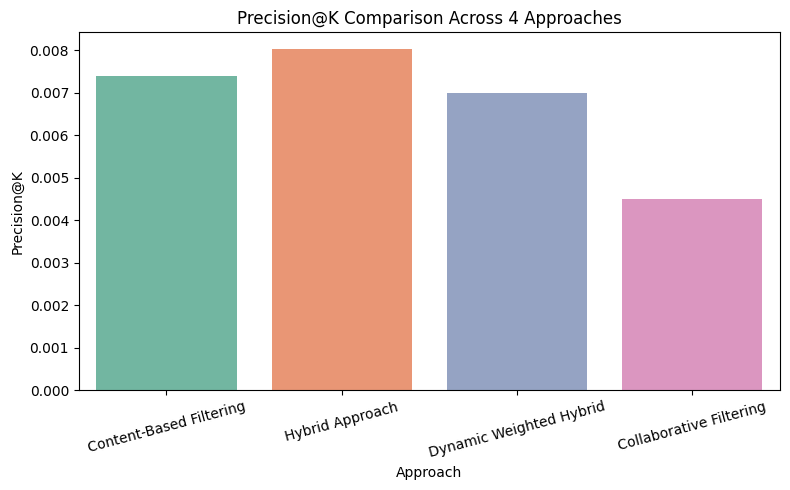

/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


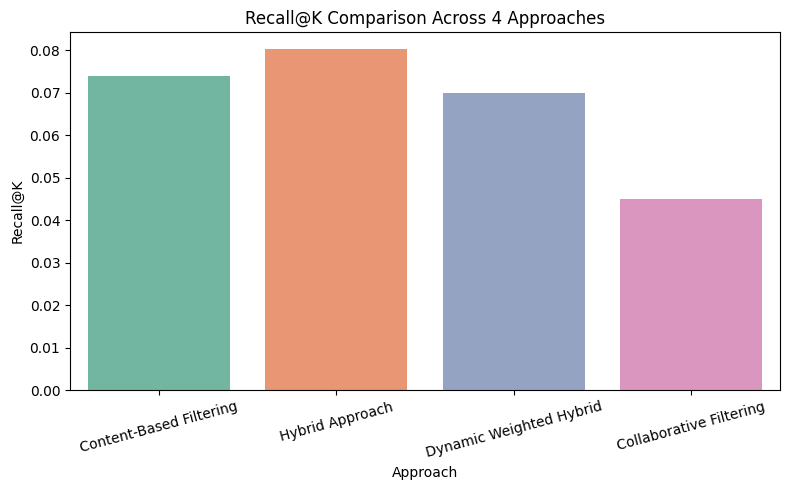

/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


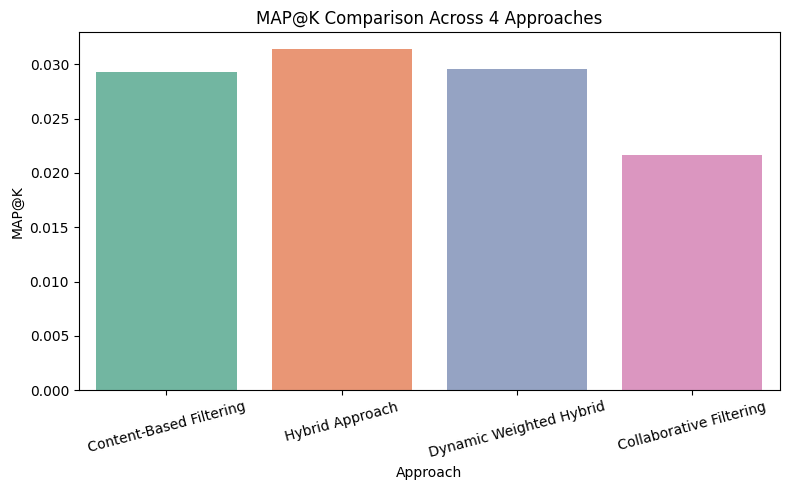

/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


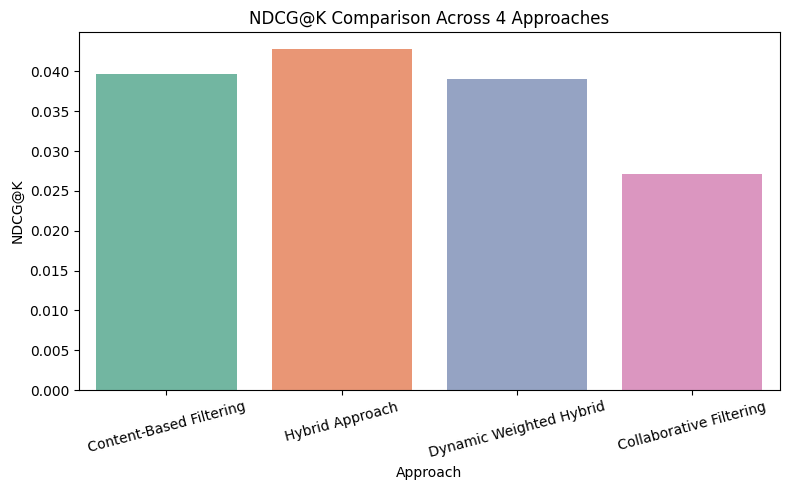

/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


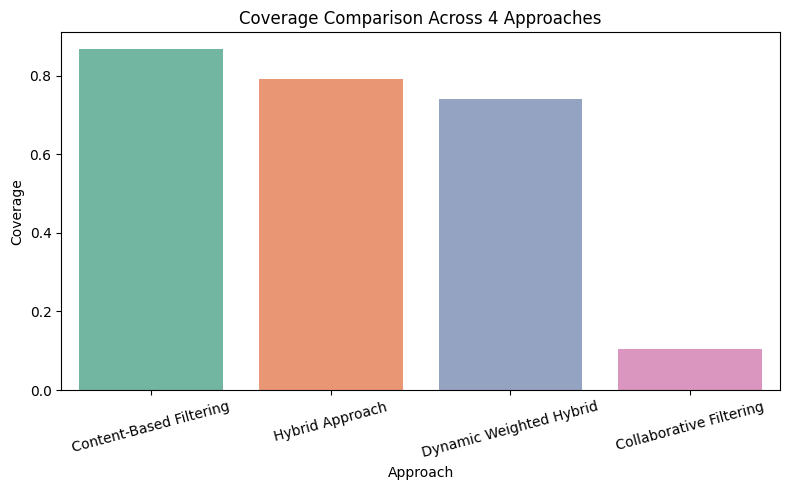

/tmp/ipykernel_13992/1196883814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')


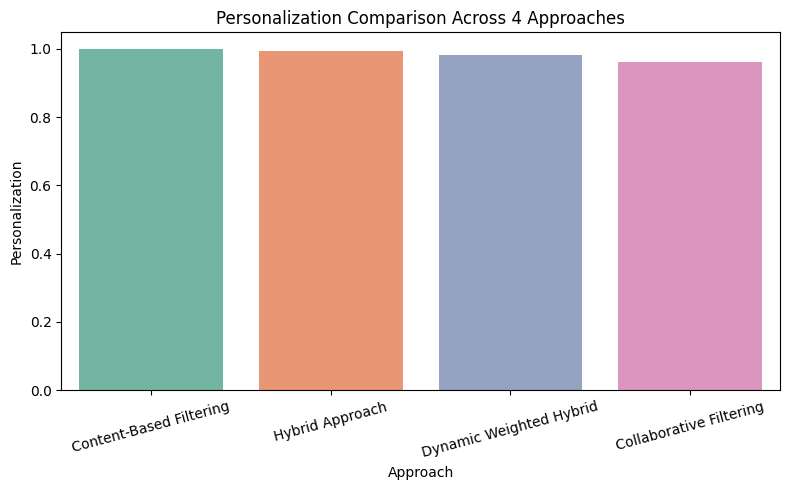

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ['Precision@K', 'Recall@K', 'MAP@K', 'NDCG@K', 'Coverage', 'Personalization']

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=results_df, x='Approach', y=metric, palette='Set2')
    plt.title(f'{metric} Comparison Across 4 Approaches')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


In [ ]:
results_df['Composite Score'] = (
    0.40 * results_df['NDCG@K'] +
    0.30 * results_df['MAP@K'] +
    0.20 * results_df['Precision@K'] +
    0.10 * results_df['Recall@K']
)


In [ ]:
results_df = results_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)
results_df


,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users,Composite Score
0,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228,0.036140
1,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228,0.033502
2,Dynamic Weighted Hybrid,0.006981,0.069808,0.029602,0.038993,0.741362,0.981197,10228,0.032855
3,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228,0.022744


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [ ]:
results_df


,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users,Composite Score
0,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228,0.036140
1,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228,0.033502
2,Dynamic Weighted Hybrid,0.006981,0.069808,0.029602,0.038993,0.741362,0.981197,10228,0.032855
3,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228,0.022744


In [ ]:
accuracy_metrics = ['Precision@K', 'Recall@K', 'MAP@K', 'NDCG@K']
results_df[ ['Approach'] + accuracy_metrics + ['Composite Score'] ]


,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Composite Score
0,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.036140
1,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.033502
2,Dynamic Weighted Hybrid,0.006981,0.069808,0.029602,0.038993,0.032855
3,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.022744


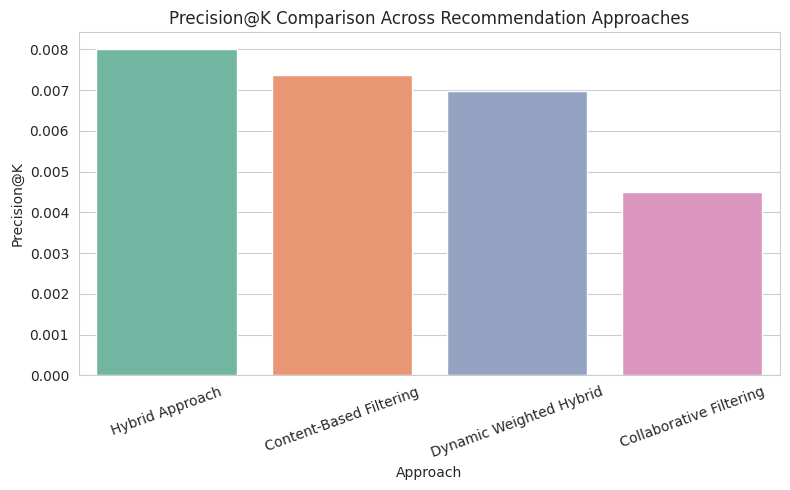

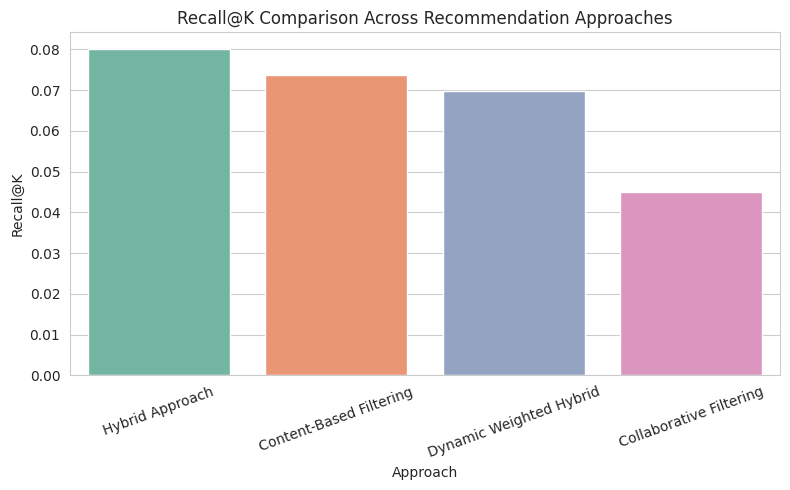

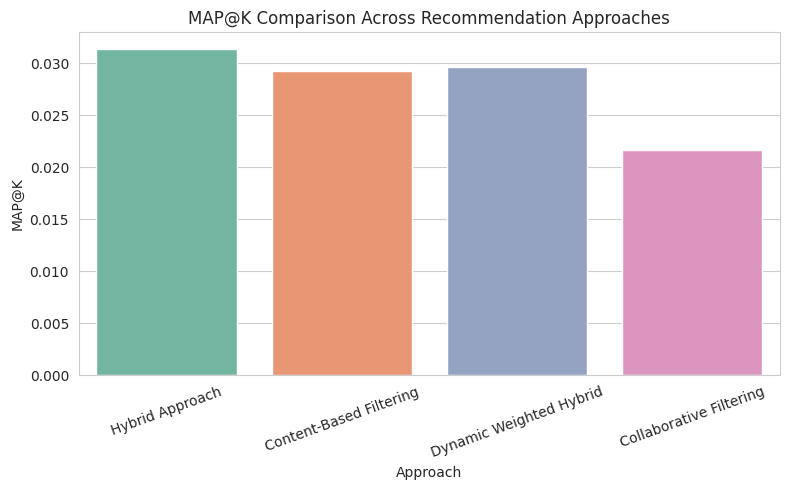

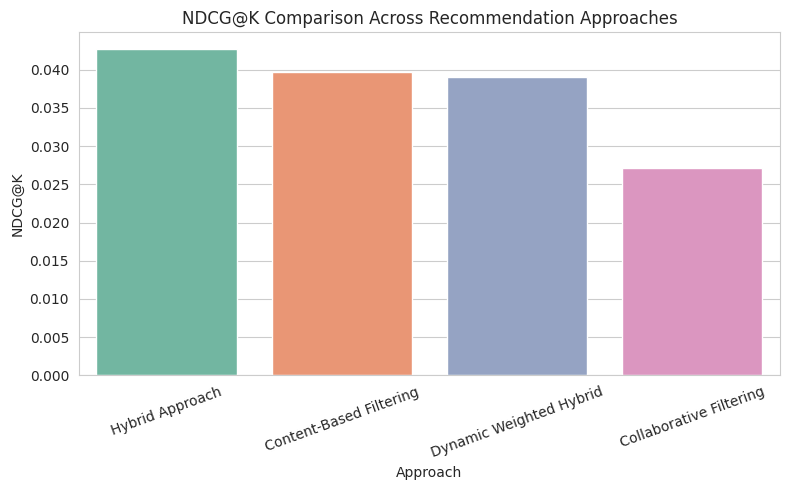

In [ ]:
for metric in accuracy_metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=results_df, x='Approach', y=metric, hue='Approach', palette='Set2', legend=False)
    plt.title(f'{metric} Comparison Across Recommendation Approaches')
    plt.xlabel('Approach')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


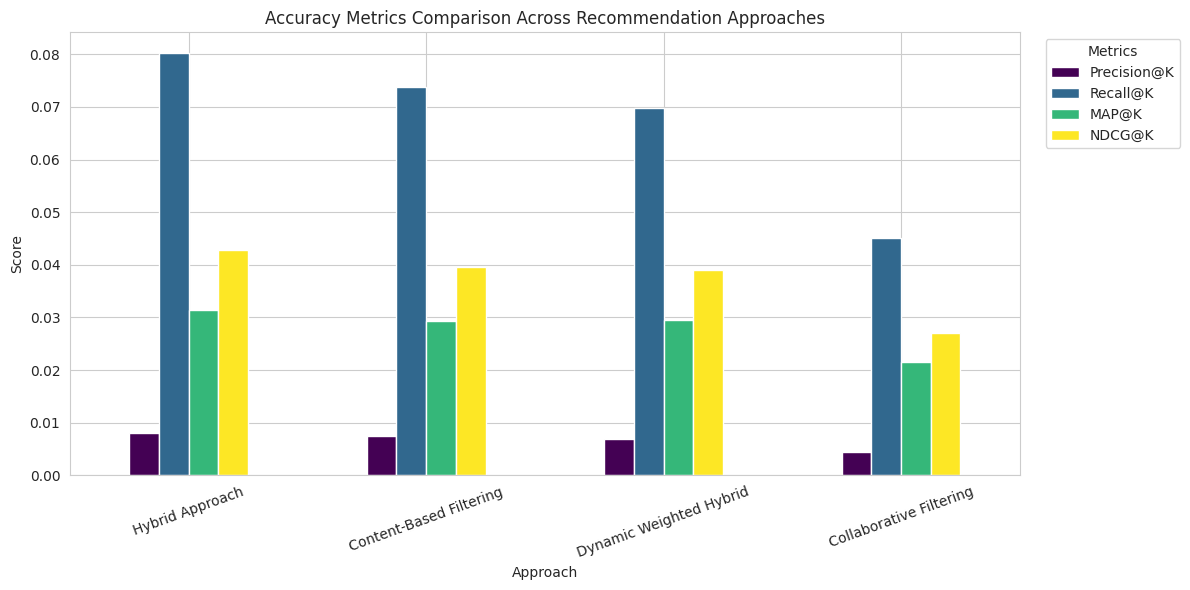

In [ ]:
accuracy_df = results_df.set_index('Approach')[accuracy_metrics]

accuracy_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Accuracy Metrics Comparison Across Recommendation Approaches')
plt.xlabel('Approach')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


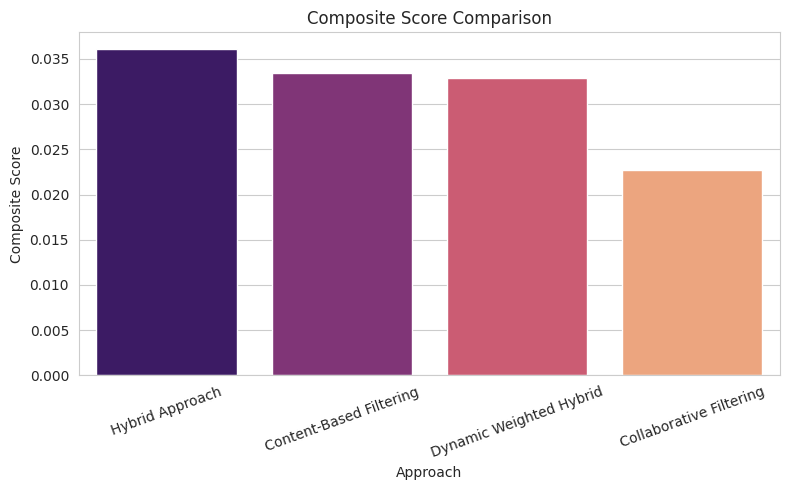

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Approach', y='Composite Score', hue='Approach', palette='magma', legend=False)
plt.title('Composite Score Comparison')
plt.xlabel('Approach')
plt.ylabel('Composite Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


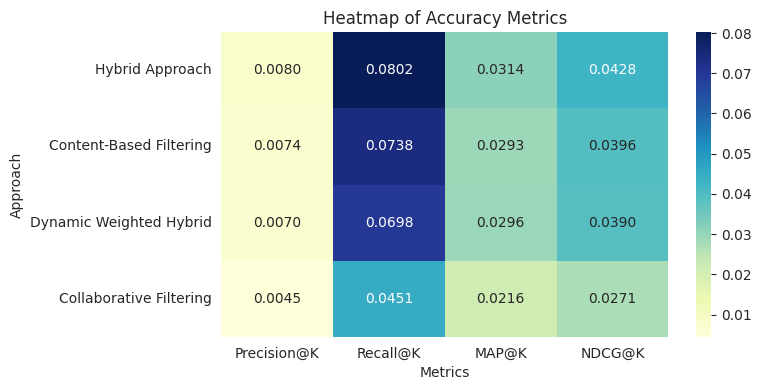

In [ ]:
heatmap_df = results_df.set_index('Approach')[accuracy_metrics]

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Heatmap of Accuracy Metrics')
plt.xlabel('Metrics')
plt.ylabel('Approach')
plt.tight_layout()
plt.show()


In [ ]:
results_df['Composite Score'] = (
    0.40 * results_df['NDCG@K'] +
    0.30 * results_df['MAP@K'] +
    0.20 * results_df['Precision@K'] +
    0.10 * results_df['Recall@K']
)

results_df = results_df.sort_values('Composite Score', ascending=False).reset_index(drop=True)
results_df


,Approach,Precision@K,Recall@K,MAP@K,NDCG@K,Coverage,Personalization,Evaluated Users,Composite Score
0,Hybrid Approach,0.008017,0.080172,0.031388,0.042758,0.792465,0.992513,10228,0.036140
1,Content-Based Filtering,0.007382,0.073817,0.029289,0.039643,0.866797,0.998163,10228,0.033502
2,Dynamic Weighted Hybrid,0.006981,0.069808,0.029602,0.038993,0.741362,0.981197,10228,0.032855
3,Collaborative Filtering,0.004507,0.045072,0.021620,0.027123,0.104312,0.961500,10228,0.022744


Popularity Bias: Recommending mostly popular items
Thematic Bias: How well recommendations match user interests